# Task 1
## Data import

In [1]:
import pandas as pd

df = pd.read_csv('02 Myocardial infarction complications Database.csv')
df.head()

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,1,0,0,0
4,5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
print(df.columns.values)

['ID' 'AGE' 'SEX' 'INF_ANAM' 'STENOK_AN' 'FK_STENOK' 'IBS_POST' 'IBS_NASL'
 'GB' 'SIM_GIPERT' 'DLIT_AG' 'ZSN_A' 'nr_11' 'nr_01' 'nr_02' 'nr_03'
 'nr_04' 'nr_07' 'nr_08' 'np_01' 'np_04' 'np_05' 'np_07' 'np_08' 'np_09'
 'np_10' 'endocr_01' 'endocr_02' 'endocr_03' 'zab_leg_01' 'zab_leg_02'
 'zab_leg_03' 'zab_leg_04' 'zab_leg_06' 'S_AD_KBRIG' 'D_AD_KBRIG'
 'S_AD_ORIT' 'D_AD_ORIT' 'O_L_POST' 'K_SH_POST' 'MP_TP_POST' 'SVT_POST'
 'GT_POST' 'FIB_G_POST' 'ant_im' 'lat_im' 'inf_im' 'post_im' 'IM_PG_P'
 'ritm_ecg_p_01' 'ritm_ecg_p_02' 'ritm_ecg_p_04' 'ritm_ecg_p_06'
 'ritm_ecg_p_07' 'ritm_ecg_p_08' 'n_r_ecg_p_01' 'n_r_ecg_p_02'
 'n_r_ecg_p_03' 'n_r_ecg_p_04' 'n_r_ecg_p_05' 'n_r_ecg_p_06'
 'n_r_ecg_p_08' 'n_r_ecg_p_09' 'n_r_ecg_p_10' 'n_p_ecg_p_01'
 'n_p_ecg_p_03' 'n_p_ecg_p_04' 'n_p_ecg_p_05' 'n_p_ecg_p_06'
 'n_p_ecg_p_07' 'n_p_ecg_p_08' 'n_p_ecg_p_09' 'n_p_ecg_p_10'
 'n_p_ecg_p_11' 'n_p_ecg_p_12' 'fibr_ter_01' 'fibr_ter_02' 'fibr_ter_03'
 'fibr_ter_05' 'fibr_ter_06' 'fibr_ter_07' 'fibr_ter_08' '

## Train-test split

In [3]:
y = df['ZSN']
X = df.drop('ZSN', axis=1)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)

(1190, 123)


## EDA
### Overview

In [5]:
X_train.describe()

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,REC_IM,P_IM_STEN,LET_IS
count,1190.000000,1184.000000,1190.000000,1188.000000,1114.000000,1142.000000,1155.000000,50.000000,1182.000000,1183.000000,...,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,845.112605,61.869932,0.615966,0.552189,2.364452,1.250438,1.183550,0.400000,1.436548,0.035503,...,0.012605,0.027731,0.038655,0.033613,0.100000,0.031933,0.038655,0.098319,0.086555,0.460504
std,492.112611,11.315202,0.486570,0.832048,2.428128,1.036737,0.791576,0.494872,1.083609,0.185126,...,0.111609,0.164270,0.192853,0.180308,0.300126,0.175895,0.192853,0.297871,0.281300,1.345848
min,1.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,419.250000,54.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,851.500000,63.000000,1.000000,0.000000,2.000000,2.000000,1.000000,0.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1259.500000,70.000000,1.000000,1.000000,5.000000,2.000000,2.000000,1.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1700.000000,92.000000,1.000000,3.000000,6.000000,4.000000,2.000000,1.000000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [6]:
# Check for missing values
missing_values = X_train.isnull().sum()
columns = X_train.columns
print("Missing values in each column:")
for col, missing in zip(columns, missing_values):
    print(f"{col}: {missing}")

Missing values in each column:
ID: 0
AGE: 6
SEX: 0
INF_ANAM: 2
STENOK_AN: 76
FK_STENOK: 48
IBS_POST: 35
IBS_NASL: 1140
GB: 8
SIM_GIPERT: 7
DLIT_AG: 183
ZSN_A: 41
nr_11: 14
nr_01: 14
nr_02: 14
nr_03: 14
nr_04: 14
nr_07: 14
nr_08: 14
np_01: 14
np_04: 14
np_05: 14
np_07: 14
np_08: 14
np_09: 14
np_10: 14
endocr_01: 9
endocr_02: 9
endocr_03: 9
zab_leg_01: 7
zab_leg_02: 7
zab_leg_03: 7
zab_leg_04: 7
zab_leg_06: 7
S_AD_KBRIG: 750
D_AD_KBRIG: 750
S_AD_ORIT: 194
D_AD_ORIT: 194
O_L_POST: 8
K_SH_POST: 11
MP_TP_POST: 9
SVT_POST: 8
GT_POST: 8
FIB_G_POST: 8
ant_im: 62
lat_im: 59
inf_im: 60
post_im: 54
IM_PG_P: 1
ritm_ecg_p_01: 110
ritm_ecg_p_02: 110
ritm_ecg_p_04: 110
ritm_ecg_p_06: 110
ritm_ecg_p_07: 110
ritm_ecg_p_08: 110
n_r_ecg_p_01: 84
n_r_ecg_p_02: 84
n_r_ecg_p_03: 84
n_r_ecg_p_04: 84
n_r_ecg_p_05: 84
n_r_ecg_p_06: 84
n_r_ecg_p_08: 84
n_r_ecg_p_09: 84
n_r_ecg_p_10: 84
n_p_ecg_p_01: 84
n_p_ecg_p_03: 84
n_p_ecg_p_04: 84
n_p_ecg_p_05: 84
n_p_ecg_p_06: 84
n_p_ecg_p_07: 84
n_p_ecg_p_08: 84
n_p_ecg_

### Nan-value imputation

In [7]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)

In [8]:
X_test = imputer.transform(X_test)
X_test = pd.DataFrame(X_test, columns=X_train.columns)

### U-Map

C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


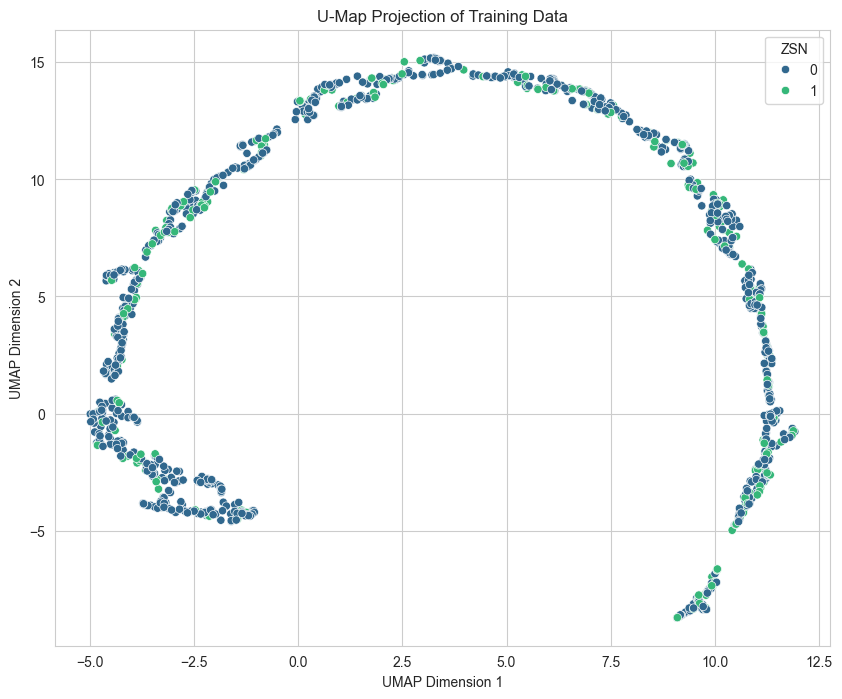

In [9]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_train)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train, palette='viridis')
plt.title('U-Map Projection of Training Data')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='ZSN', loc='best')
plt.show()

### PCA

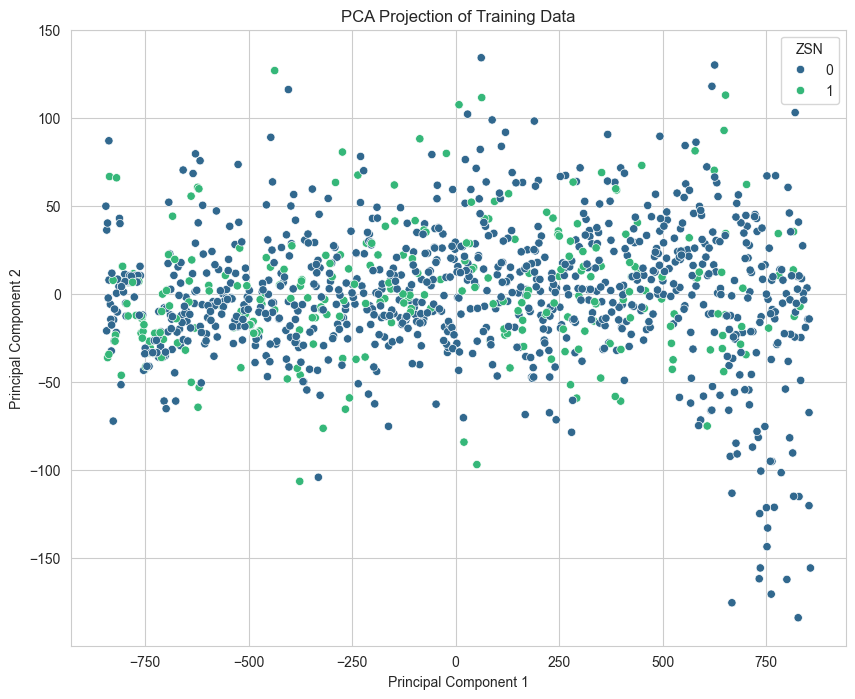

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis')
plt.title('PCA Projection of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='ZSN', loc='best')
plt.show()

### T-SNE

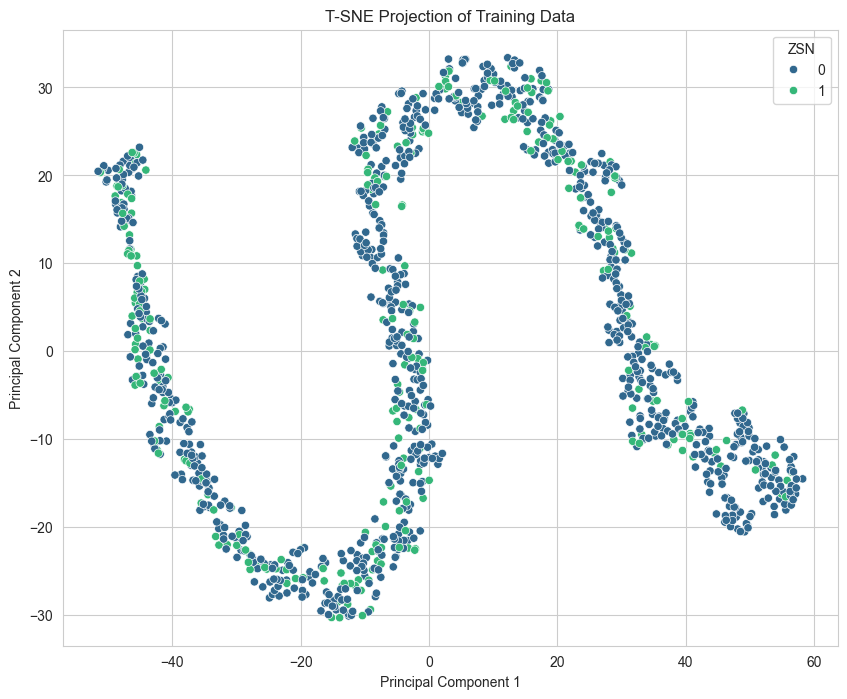

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], hue=y_train, palette='viridis')
plt.title('T-SNE Projection of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='ZSN', loc='best')
plt.show()


## Model training
### Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=50000)
logreg.fit(X_train, y_train)

test_score_logreg = logreg.score(X_test, y_test)
print(f'Logistic Regression Test Score: {test_score_logreg:.4f}')

Logistic Regression Test Score: 0.7745


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 12768 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
test_score_rf = rf.score(X_test, y_test)
print(f'Random Forest Test Score: {test_score_rf:.4f}')

Random Forest Test Score: 0.8098


### KNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
test_score_knn = knn.score(X_test, y_test)
print(f'KNN Test Score: {test_score_knn:.4f}')

KNN Test Score: 0.7235


### XGBoost

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
test_score_xgb = xgb.score(X_test, y_test)
print(f'XGBoost Test Score: {test_score_xgb:.4f}')

XGBoost Test Score: 0.8078


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:17:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model explanations

### Logistic Regression

In [16]:
feature_importance_logreg = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(ascending=False)
print("Logistic Regression Feature Importance:")
print(feature_importance_logreg)

Logistic Regression Feature Importance:
DRESSLER         1.466294
n_r_ecg_p_06     1.255765
FIBR_PREDS       1.139043
n_p_ecg_p_04     0.957939
zab_leg_01       0.865079
                   ...   
FIB_G_POST      -0.663477
RAZRIV          -0.680068
ritm_ecg_p_04   -1.032022
endocr_03       -1.224559
K_SH_POST       -1.311925
Length: 123, dtype: float64


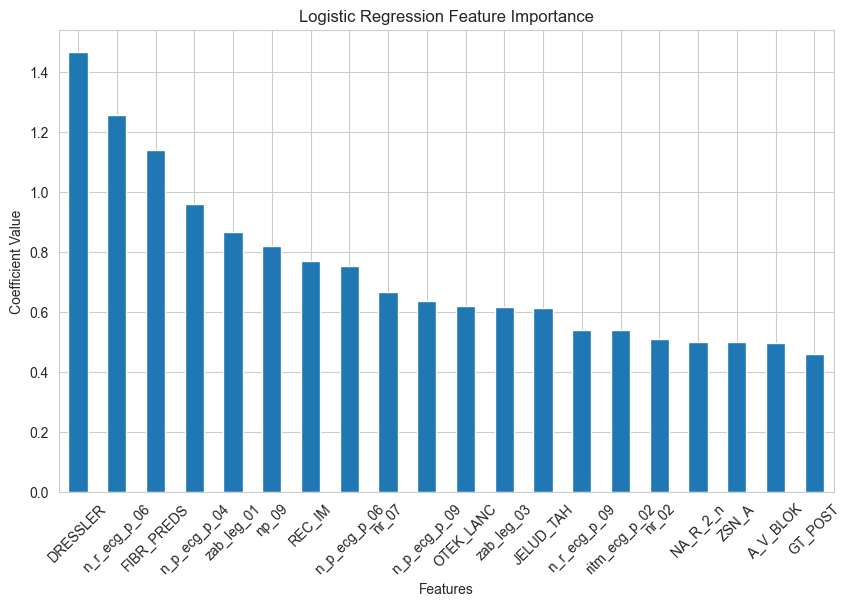

In [17]:
plt.figure(figsize=(10, 6))
feature_importance_logreg[:20].plot(kind='bar')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()

### Random Forest

In [18]:
feature_importance_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:")
print(feature_importance_rf)

Random Forest Feature Importance:
ZSN_A           0.070129
ID              0.051597
AGE             0.038237
L_BLOOD         0.036814
ROE             0.033518
                  ...   
n_r_ecg_p_08    0.000037
np_07           0.000000
np_04           0.000000
fibr_ter_08     0.000000
n_p_ecg_p_05    0.000000
Length: 123, dtype: float64


### KNN

### XGBoost

In [19]:
feature_importance_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("XGBoost Feature Importance:")
print(feature_importance_xgb)

XGBoost Feature Importance:
ZSN_A           0.058621
GIPER_NA        0.045332
zab_leg_03      0.040165
NA_R_3_n        0.034099
n_r_ecg_p_06    0.026863
                  ...   
TIKL_S_n        0.000000
PREDS_TAH       0.000000
RAZRIV          0.000000
FIBR_JELUD      0.000000
A_V_BLOK        0.000000
Length: 123, dtype: float32


## LIME

In [20]:
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(class_names=['Yes', 'No'], feature_names=X_train.columns, training_data=X_train.values)
exp = explainer.explain_instance(X_test.iloc[0].values, xgb.predict_proba, num_features=10)

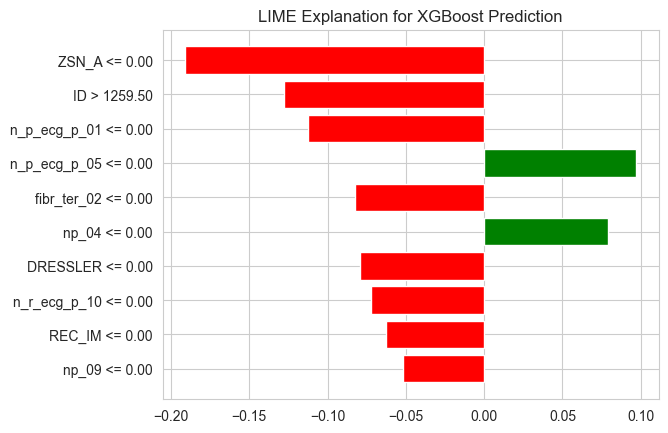

In [21]:
fig = exp.as_pyplot_figure()
plt.title('LIME Explanation for XGBoost Prediction')
plt.show()

## Shap values

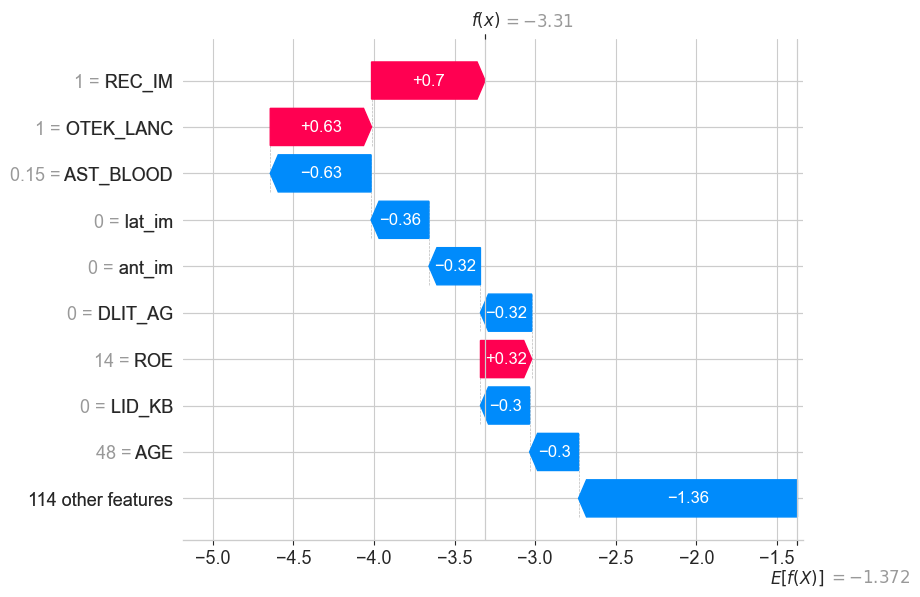

In [22]:
import shap

explainer_shap = shap.Explainer(xgb)
shap_values = explainer_shap(X_train)
shap.plots.waterfall(shap_values[0])

## Conclusion
ZSN_A is the most important feature. This is because it has target information which leaks into the model. 

# Task 1 without ZSN_A

In [23]:
X_train_no_leak = X_train.drop('ZSN_A', axis=1)
X_test_no_leak = X_test.drop('ZSN_A', axis=1)

In [24]:
logreg = LogisticRegression(max_iter=50000)
logreg.fit(X_train_no_leak, y_train)

test_score_logreg = logreg.score(X_test_no_leak, y_test)
print(f'Logistic Regression Test Score: {test_score_logreg:.4f}')

Logistic Regression Test Score: 0.7706


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 12746 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_no_leak, y_train)
test_score_rf = rf.score(X_test_no_leak, y_test)
print(f'Random Forest Test Score: {test_score_rf:.4f}')

Random Forest Test Score: 0.7706


In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_no_leak, y_train)
test_score_knn = knn.score(X_test_no_leak, y_test)
print(f'KNN Test Score: {test_score_knn:.4f}')

KNN Test Score: 0.7235


In [27]:


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_no_leak, y_train)
test_score_xgb = xgb.score(X_test_no_leak, y_test)
print(f'XGBoost Test Score: {test_score_xgb:.4f}')

XGBoost Test Score: 0.7588


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:17:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
feature_importance_logreg = pd.Series(logreg.coef_[0], index=X_train_no_leak.columns).sort_values(ascending=False)
print("Logistic Regression Feature Importance:")
print(feature_importance_logreg)

Logistic Regression Feature Importance:
DRESSLER         1.425904
n_r_ecg_p_06     1.211891
FIBR_PREDS       1.122029
zab_leg_01       0.892089
n_p_ecg_p_06     0.870886
                   ...   
FIB_G_POST      -0.648326
RAZRIV          -0.666615
ritm_ecg_p_04   -1.105629
endocr_03       -1.128799
K_SH_POST       -1.298297
Length: 122, dtype: float64


In [29]:
feature_importance_rf = pd.Series(rf.feature_importances_, index=X_train_no_leak.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:")
print(feature_importance_rf)

Random Forest Feature Importance:
ID             0.052553
L_BLOOD        0.039883
ROE            0.039877
AGE            0.039262
S_AD_KBRIG     0.035881
                 ...   
np_08          0.000023
fibr_ter_08    0.000008
np_04          0.000000
np_07          0.000000
fibr_ter_07    0.000000
Length: 122, dtype: float64


In [30]:
feature_importance_xgb = pd.Series(xgb.feature_importances_, index=X_train_no_leak.columns).sort_values(ascending=False)
print("XGBoost Feature Importance:")
print(feature_importance_xgb)

XGBoost Feature Importance:
n_r_ecg_p_06    0.035143
NA_R_3_n        0.031810
NOT_NA_3_n      0.031802
fibr_ter_03     0.031157
MP_TP_POST      0.030837
                  ...   
n_p_ecg_p_08    0.000000
JELUD_TAH       0.000000
PREDS_TAH       0.000000
TIKL_S_n        0.000000
FIBR_JELUD      0.000000
Length: 122, dtype: float32


LIME & SHAP for XGBoost without ZSN_A

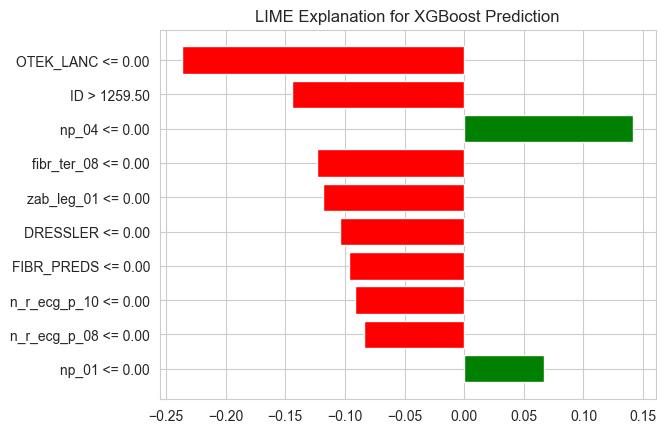

In [32]:
explainer = lime_tabular.LimeTabularExplainer(class_names=['Yes', 'No'], feature_names=X_train_no_leak.columns, training_data=X_train_no_leak.values)
exp = explainer.explain_instance(X_test_no_leak.iloc[0].values, xgb.predict_proba, num_features=10)
fig = exp.as_pyplot_figure()
plt.title('LIME Explanation for XGBoost Prediction')
plt.show()

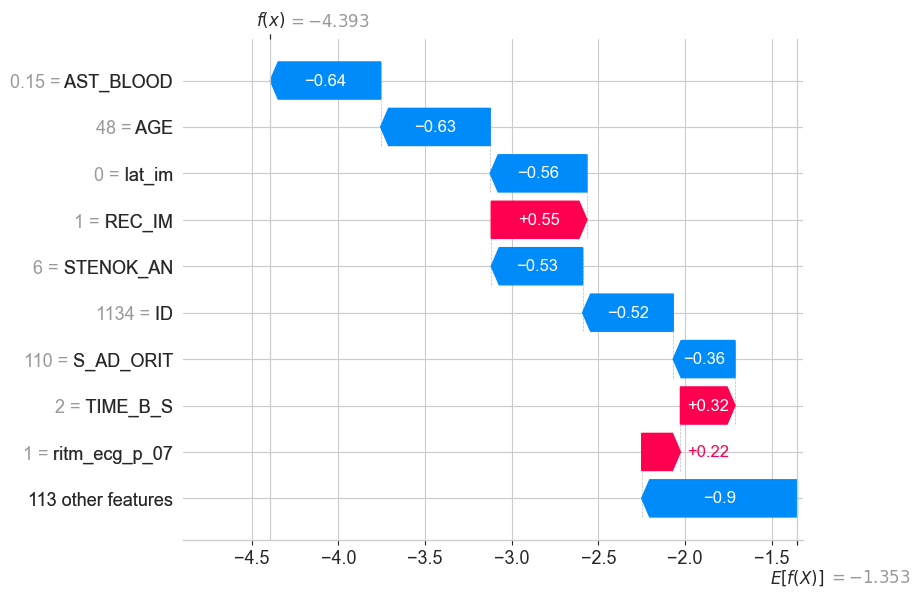

In [33]:
explainer_shap = shap.Explainer(xgb)
shap_values = explainer_shap(X_train_no_leak)
shap.plots.waterfall(shap_values[0])

# Richtig

In [34]:
import pandas as pd

df = pd.read_csv('02 Myocardial infarction complications Database.csv')
df.head()

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,...,0,0,0,0,0,0,1,0,0,0
4,5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
y = df['ZSN']
X = df.drop('ZSN', axis=1)
X = X.drop('ID', axis=1)

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)

(1190, 122)


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
test_score_xgb = xgb.score(X_test, y_test)
print(f'XGBoost Test Score: {test_score_xgb:.4f}')

XGBoost Test Score: 0.8020


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\hmbi-BpmH9xiM-py3.12\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
feature_importance_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("XGBoost Feature Importance:")
print(feature_importance_xgb)

XGBoost Feature Importance:
n_p_ecg_p_11    0.060750
ZSN_A           0.053950
NOT_NA_3_n      0.042115
n_r_ecg_p_09    0.038143
NA_R_3_n        0.032121
                  ...   
n_r_ecg_p_08    0.000000
R_AB_3_n        0.000000
JELUD_TAH       0.000000
TIKL_S_n        0.000000
PREDS_TAH       0.000000
Length: 122, dtype: float32


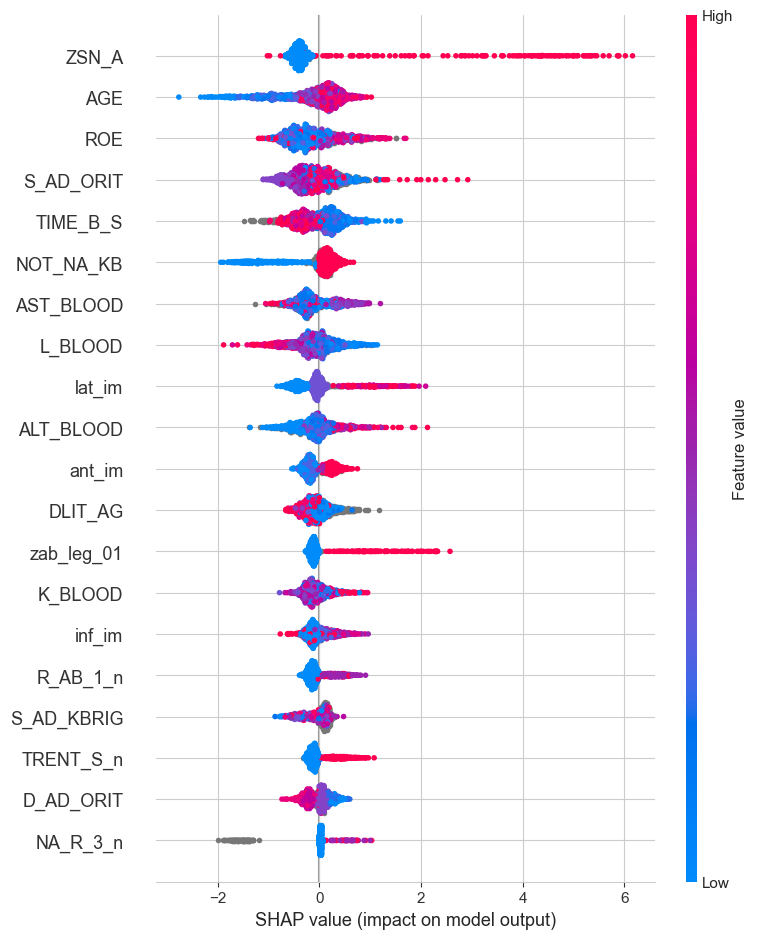

In [41]:
import shap

explainer_shap = shap.Explainer(xgb)
shap_values = explainer_shap(X_train)
shap.summary_plot(shap_values, X_train)